In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
spectrum_1 = pd.read_csv("Spectrum2s_1_noreg_gas_exp.csv")
spectrum_1 = spectrum_1.set_index('Name')
spectrum_2 = pd.read_csv("Spectrum2s_2_noreg_gas_exp.csv")
spectrum_2 = spectrum_2.set_index('Name')

SNR_HA = pd.read_csv("SNR_HA_2s.csv")
SNR_HB = pd.read_csv("SNR_HB_2s.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2_2s.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2_2s.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1_2s.csv") 

In [4]:
spectrum_1

,Flux,Error_flux
Name,,
Hbeta,0.039395,0.023919
Halpha,0.075696,0.018902
[SII]6716,0.023930,0.013617
[SII]6731,0.044012,0.018075
HeII4687,0.007135,0.012772
HeI5876,0.013922,0.016074
[OIII]4959,0.012526,0.014729
[OIII]5007,0.037578,0.014729
[OI]6300,0.050591,0.057344


In [5]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    e_1 = err_1/(flux_1*np.log(10))
    e_2 = err_2/(flux_2*np.log(10))
    print(np.sqrt((e_1)**2+(e_2)**2))
    return np.sqrt((e_1)**2+(e_2)**2)

def ratio(spectrum):
    OIII_HB = spectrum.loc['[OIII]5007', 'Flux']/spectrum.loc['Hbeta', 'Flux']
    NII_HA = spectrum.loc['[NII]6583', 'Flux']/spectrum.loc['Halpha', 'Flux']
    SII_HA = spectrum.loc['[SII]6716', 'Flux']/spectrum.loc['Halpha', 'Flux']
    err_OIII_HB = error_ratio(spectrum.loc['[OIII]5007', 'Error_flux'], spectrum.loc['Hbeta', 'Error_flux'], spectrum.loc['[OIII]5007', 'Flux'], spectrum.loc['Hbeta', 'Flux'])
    err_NII_HA = error_ratio(spectrum.loc['[NII]6583', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[NII]6583', 'Flux'], spectrum.loc['Halpha', 'Flux'])
    err_SII_HA = error_ratio(spectrum.loc['[SII]6716', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[SII]6716', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('HB<0 but OIII>3')
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('All ok')
        return True 
    else: 
        print('False')
        return False 

In [6]:
for i in range(2):
    print(i+1)
    evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])

1
False
2
All ok


0.3138518432044792
0.2557647817066661
0.2698758667632043
0.07172043357954762
0.04273080595314155
0.014718862137121107


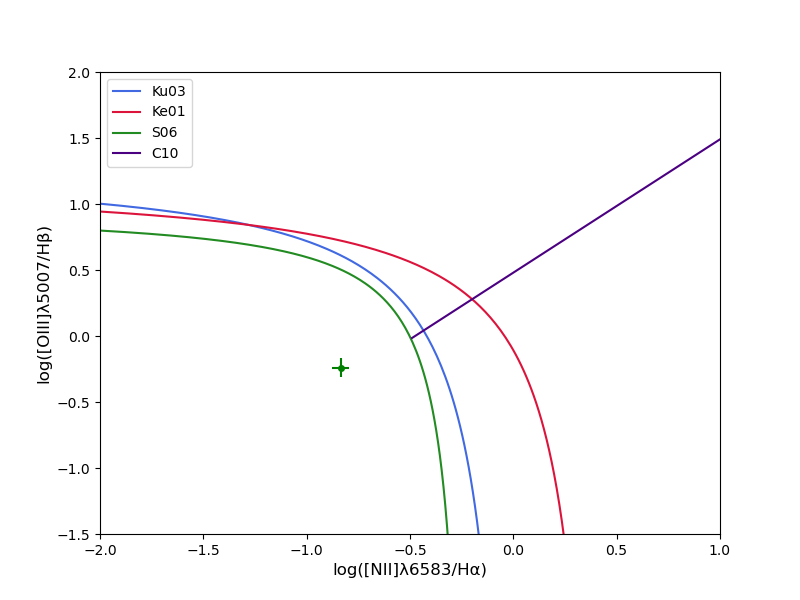

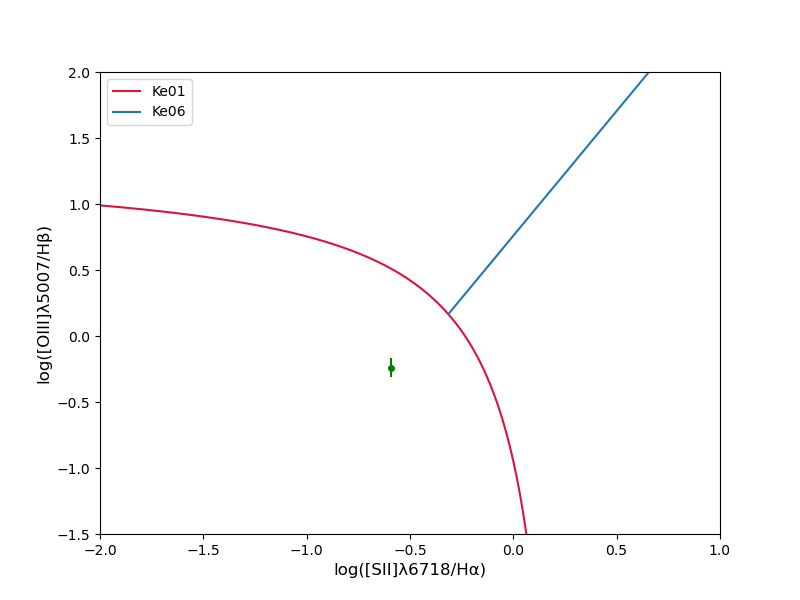

In [7]:
plt.figure(figsize=(8,6))

OIII_HB_1, NII_HA_1, SII_HA_1, err_OIII_HB_1, err_NII_HA_1, err_SII_HA_1 = ratio(spectrum_1)
OIII_HB_2, NII_HA_2, SII_HA_2, err_OIII_HB_2, err_NII_HA_2, err_SII_HA_2 = ratio(spectrum_2)
#OIII_HB_3, NII_HA_3, SII_HA_3, err_OIII_HB_3, err_NII_HA_3, err_SII_HA_3 = ratio(spectrum_3)
#OIII_HB_4, NII_HA_4, SII_HA_4, err_OIII_HB_4, err_NII_HA_4, err_SII_HA_4 = ratio(spectrum_4)
#OIII_HB_5, NII_HA_5, SII_HA_5, err_OIII_HB_5, err_NII_HA_5, err_SII_HA_5 = ratio(spectrum_5)

#plt.errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
plt.plot(x3, C10(x3), label = 'C10', color = 'indigo')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_2s', bbox_inches='tight')

plt.figure(figsize=(8,6))

#plt.errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_2s', bbox_inches='tight')

## BPT con correzioni

In [8]:
areas_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/Contaminations/Areas_OIII_2s.csv",
                        index_col = 0)
areas_NII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/Contaminations/Areas_NII_2s.csv",
                        index_col = 0)
areas_SII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/Contaminations/Areas_SII_2s.csv",
                        index_col = 0)
areas_Halpha = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/Contaminations/Areas_Halpha_2s.csv",
                        index_col = 0)
areas_Hbeta = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/Contaminations/Areas_Hbeta_2s.csv",
                        index_col = 0)

In [9]:
def true_flux(spectrum1, spectrum2, area, e_1, e_2):
    riga_1 = spectrum1*area['Peak 1'].iloc[0]/100
    err_1 = riga_1 * 0.1
    
    riga_2 = spectrum2 * area['Peak 2'].iloc[1]/100
    err_2 = riga_2 * 0.1
 
    return riga_1, riga_2, err_1, err_2

def ratio_true(OIII, HB, HA, NII, SII, err_OIII, err_HB, err_HA, err_NII, err_SII):
    OIII_HB_true = OIII/HB
    NII_HA_true = NII/HA
    SII_HA_true = SII/HA
    err_OIII_HB_true = error_ratio(err_OIII, err_HB, OIII, HB)
    err_NII_HA_true = error_ratio(err_NII, err_HA, NII, HA)
    err_SII_HA_true = error_ratio(err_SII, err_HA, SII, HA)
    return OIII_HB_true, NII_HA_true, SII_HA_true, err_OIII_HB_true, err_SII_HA_true, err_NII_HA_true

In [10]:
OIII_1, OIII_2, err_OIII_1, err_OIII_2 = true_flux(spectrum_1.loc['[OIII]5007', 'Flux'], spectrum_2.loc['[OIII]5007', 'Flux'], areas_OIII,
                                                                                          spectrum_1.loc['[OIII]5007', 'Error_flux'], spectrum_2.loc['[OIII]5007', 'Error_flux'])                                 
HB_1, HB_2, err_HB_1, err_HB_2 = true_flux(spectrum_1.loc['Hbeta', 'Flux'], spectrum_2.loc['Hbeta', 'Flux'],  areas_Hbeta,
                                                    spectrum_1.loc['Hbeta', 'Error_flux'], spectrum_2.loc['Hbeta', 'Error_flux'])
HA_1, HA_2, err_HA_1, err_HA_2 = true_flux(spectrum_1.loc['Halpha', 'Flux'], spectrum_2.loc['Halpha', 'Flux'], areas_Halpha,
                                                    spectrum_1.loc['Halpha', 'Error_flux'], spectrum_2.loc['Halpha', 'Error_flux'])
NII_1, NII_2, err_NII_1, err_NII_2 = true_flux(spectrum_1.loc['[NII]6583', 'Flux'], spectrum_2.loc['[NII]6583', 'Flux'], areas_NII,
                                                    spectrum_1.loc['[NII]6583', 'Error_flux'], spectrum_2.loc['[NII]6583', 'Error_flux'])
SII_1, SII_2, err_SII_1, err_SII_2 = true_flux(spectrum_1.loc['[SII]6716', 'Flux'], spectrum_2.loc['[SII]6716', 'Flux'], areas_SII,
                                                    spectrum_1.loc['[SII]6716', 'Error_flux'], spectrum_2.loc['[SII]6716', 'Error_flux'])

0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.06141851463713753
0.06141851463713753


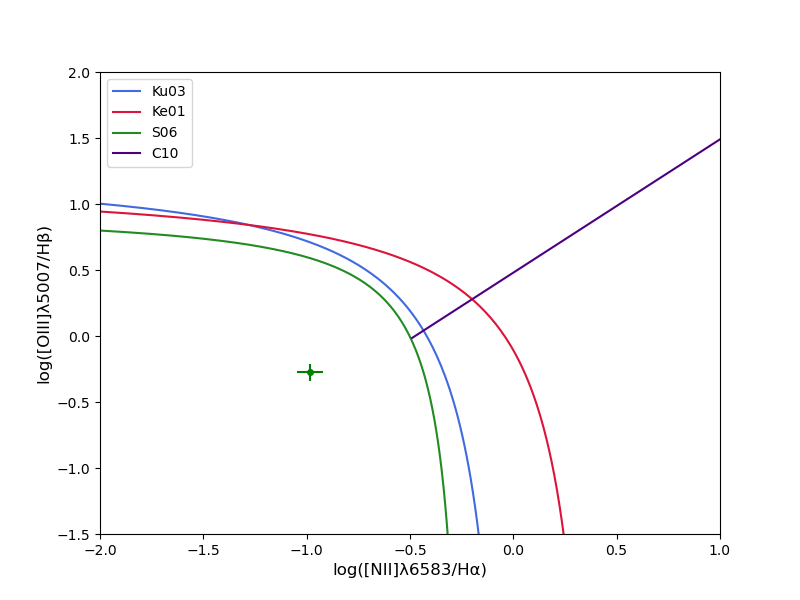

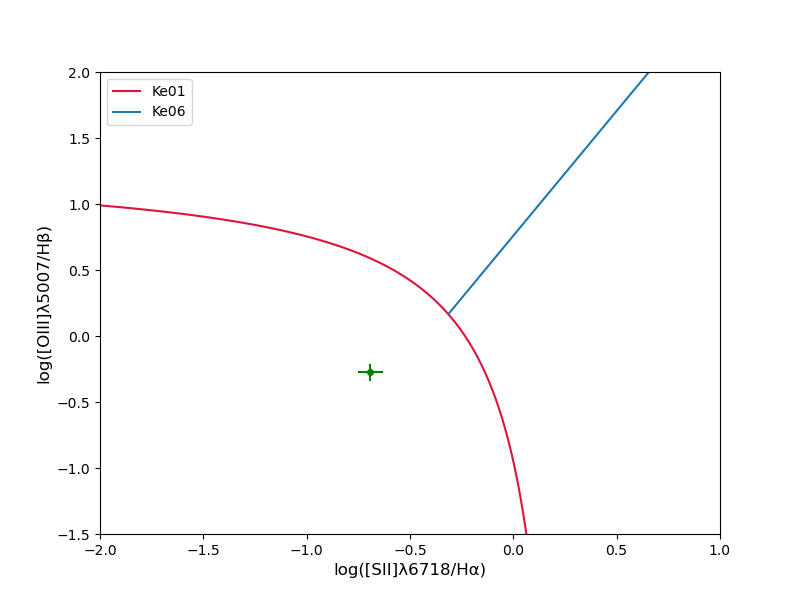

In [11]:
plt.figure(figsize=(8,6))

OIII_HB_1_true, NII_HA_1_true, SII_HA_1_true, err_OIII_HB_1_true, err_SII_HA_1_true, err_NII_HA_1_true = ratio_true(OIII_1, HB_1, HA_1, NII_1, 
                                                                                       SII_1, err_OIII_1, err_HB_1, err_HA_1, err_NII_1, err_SII_1)
OIII_HB_2_true, NII_HA_2_true, SII_HA_2_true, err_OIII_HB_2_true, err_SII_HA_2_true, err_NII_HA_2_true = ratio_true(OIII_2, HB_2, HA_2, NII_2, 
                                                                                       SII_2, err_OIII_2, err_HB_2, err_HA_2, err_NII_2, err_SII_2)

#plt.errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
plt.plot(x3, C10(x3), label = 'C10', color = 'indigo')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_2s_true', bbox_inches='tight')

plt.figure(figsize=(8,6))

#plt.errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_2s_true', bbox_inches='tight')

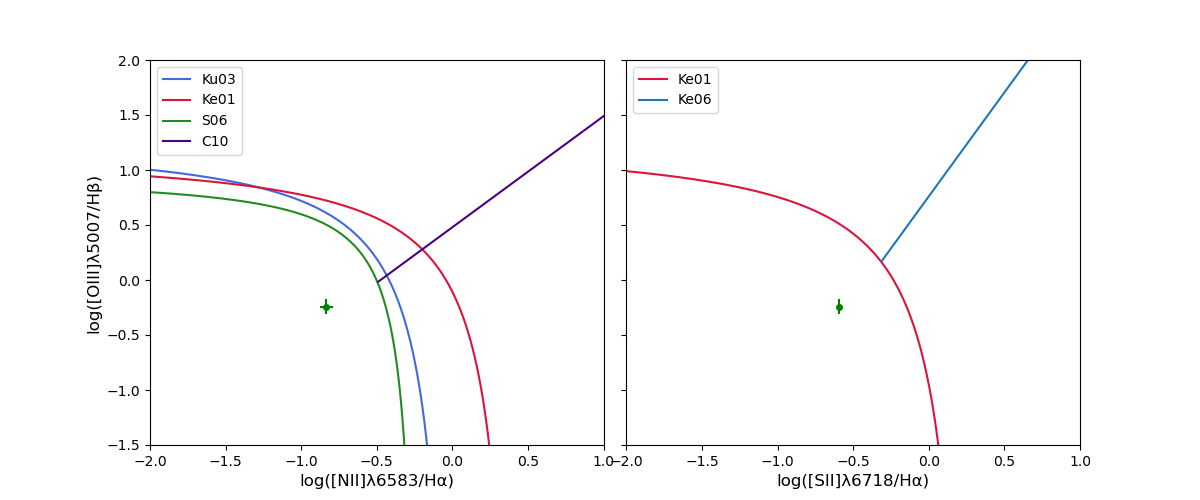

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

#ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

#ax[1].errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_2s_both.png', bbox_inches='tight')

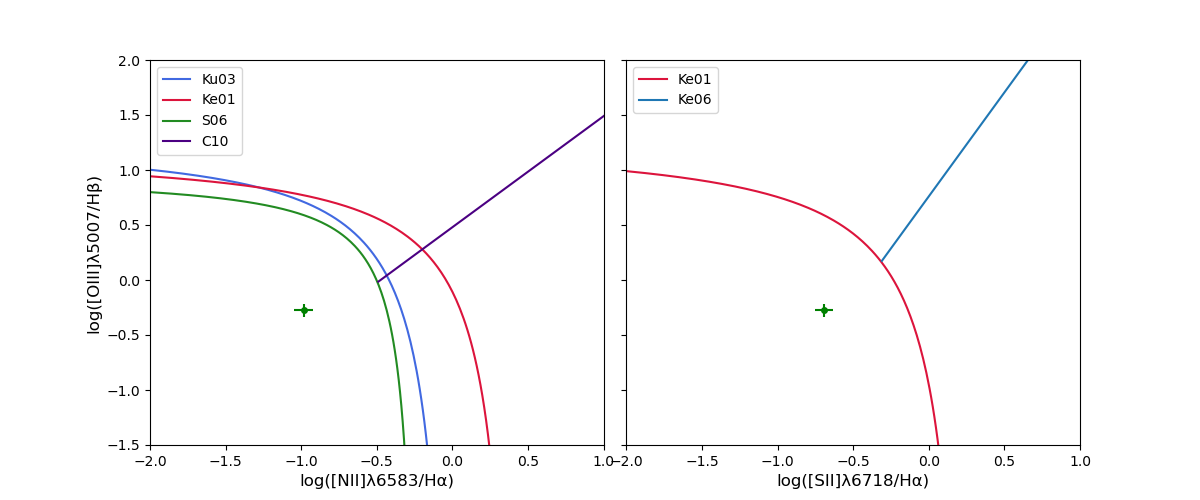

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

#ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

#ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_2s_both_true.png', bbox_inches='tight')

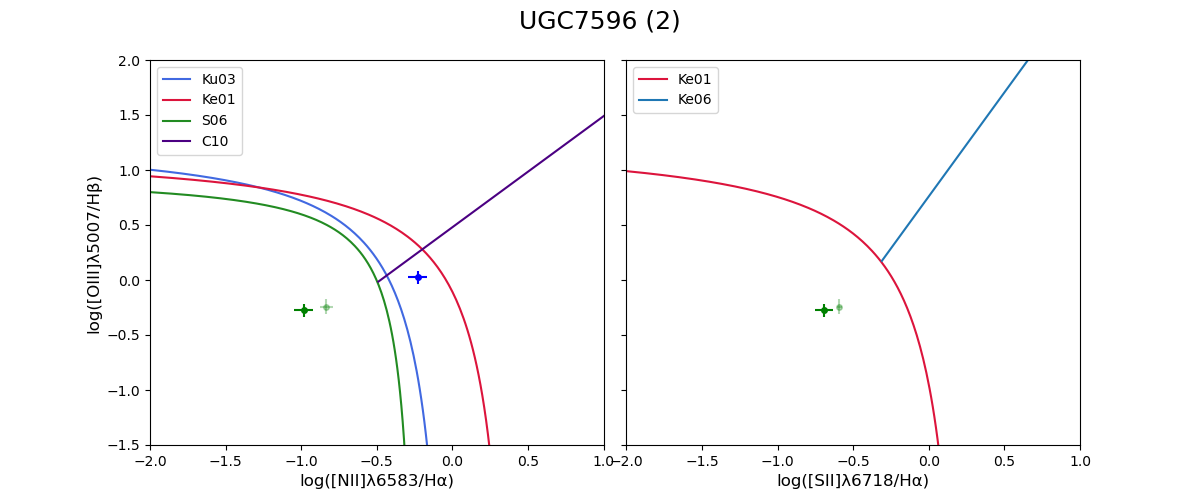

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

#ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
#ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
#ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
#ax[0].errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o', alpha = 0.3)

ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

##ax[1].errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
#ax[1].errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
#ax[1].errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
#ax[1].errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o', alpha = 0.3)

#ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
fig.suptitle('UGC7596 (2)', fontsize = 18)
plt.savefig('BPT_2s_motion.png', bbox_inches='tight')